# Определение резонансного смещения для сегмента (критерий)
Возможность настройки данного критерия через 4-ре параметра: 
{min_librations ($L_{min}$), max_consecutive_nonlib ($G_{max}$), sliding_window_size ($W$), max_nonlib_in_sliding ($Y$)}

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
#Импорты функций из модулей
from src.time_series import load_multi_csv
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions
from src.criteria import process_multiplet

2026-05-05 13:42:40.690766: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Загрузка файла с углами и преобразование в необходимые форматы для функций построений графиков и модели
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_multi_csv(
    filepath=data_path,
    angle_columns=['phi_0_original', 'phi_1_original'],  # подставьте имена ваших колонок для углов из мультиплета
    period_column='period_ratio',
    time_column='time_years',
    angle_unit='deg',
    convert_to_xy=True
)

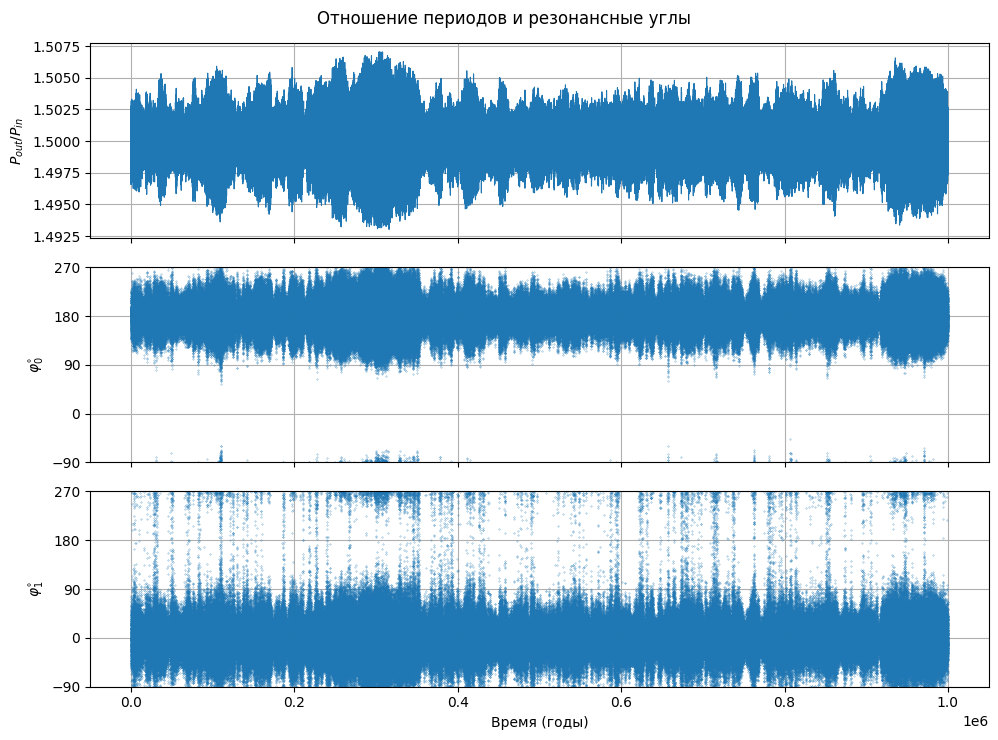

In [4]:
# Построить ряды из файла с углами и отношением периодов
plot_raw_multiplet(
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    angles_deg_list=data['angles_deg'],
    title='Отношение периодов и резонансные углы'
    # save_path=''
)

In [5]:
# Разбиение на окна (пока реализован вариант разбиения без перекрытий между окнами)
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)


In [6]:
#Загрузка обученной модели ('1' --- модель обученная на оригинальном наборе данных с дисбалансом классов, "2" --- модель обученная на урезаном наборе данных (примеры были урезаны до миноритарного класса))
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1777970580.860666   46590 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
# Прогнозы модели для окон
probs = predict_multiplet(windows['angle_windows'], model)

2026-05-05 13:43:01.762234: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 13:43:01.857883: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 13:43:01.953442: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 13:43:01.996040: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 13:43:02.074935: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.


In [8]:
# Наибольшая веротяность для каждого окна (наиболее вроятная метка <<0>> --- циркуляция, <<1>> --- либрация, <<2>> --- переходный режим)
classes = [predict_classes_from_proba(p) for p in probs]

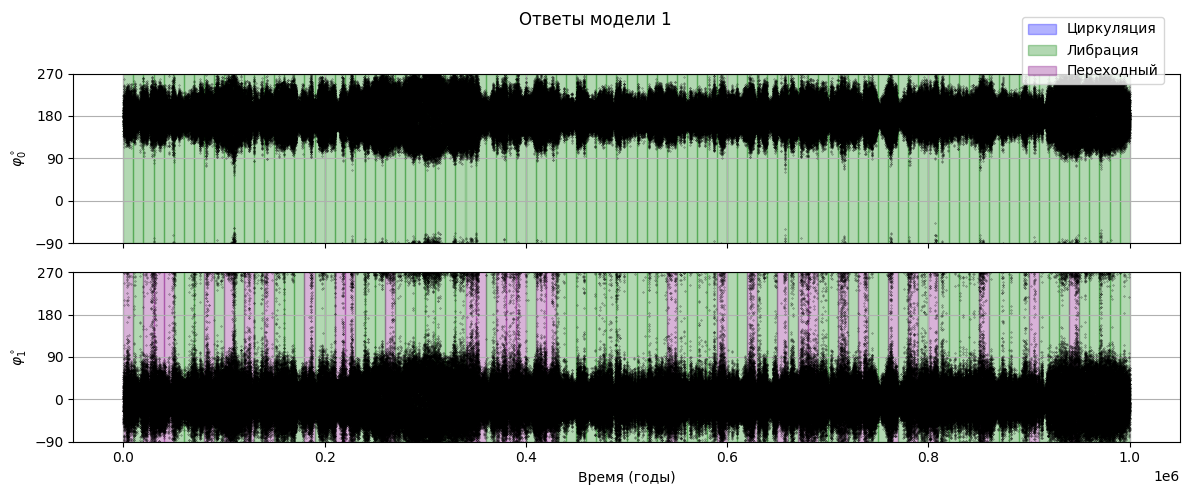

In [9]:
# Расскрасить окна на основе ответов модели (картинка)
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1',
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

Вычисление резонансных сегментов.

In [10]:
"""
В данном случае критерий: минимально необходимая длинна окон (сегмента) либрации агрегированных меток окон (>=30) (сведены к одной с приоритетом:1 (либрация) > 2 (переходный) > 0 (циркуляция))
, со скользящим окном для проверки (на 6 окон не более двух меток отличных от либрации)"""
#Критерии можно адаптировать под исследуемый ряд (окна не-либраций, можно адаптировать с учётом того, что переходный режим "2" не так сильно нарушает критерии для W и Y)
segments = process_multiplet(
    class_labels_list=classes,
    window_bounds=windows['window_bounds'],
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    expected_ratio=1.5,#резонансное отношение периодов для планет ((p+q)\p, в данном случае 3/2)
    min_librations=30,
    max_consecutive_nonlib=2,# не более двух меток отличных от либрации на скользящем окне
    sliding_window_size=6,#длина скользящего окна
    max_nonlib_in_sliding=2
)

Статистика по найденным сегментам

In [11]:
segments

[{'librations_count': 100,
  'start_window': 0,
  'end_window': 99,
  't_start_years': np.float32(0.0),
  't_end_years': np.float32(999997.5),
  'duration_years': np.float32(999997.5),
  'Delta_max': np.float32(0.0070397854)}]

In [12]:
segments[0]['duration_years']#Длительность интервала либрации

np.float32(999997.5)

Значение резонансного отступа для данного мультиплета (или просто угла) $\Delta \leq \Delta_\max$

In [13]:
segments[0]['Delta_max']# Максимально значение резонансного отступа резонанса данного резонанса 3:2 на интервале либрации между 1 и 2 планетами

np.float32(0.0070397854)